In [501]:
# all the imports 

import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [502]:
# loadig the csv file

data = pd.read_csv("housing.csv")

# checking the data for missing values

data.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [503]:
# removing rows with missing values
# since the dataset has over 20 thousand rows, we can afford to lose 207 of them with missing values

data.dropna(inplace=True)


# removing the columns that we don't need, since our research question is to find the correlation between the location and the median house value, we don't need the other columns
# data.drop(columns=["housing_median_age", "total_rooms", "total_bedrooms", "population", "households", "median_income"], inplace=True)

# checking the data for missing values

data.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [504]:
# descriptive statistics of the median_house_value column
print(f"Mean of median_house_value: {data['median_house_value'].mean():.2f}")
print(f"Median of median_house_value: {data['median_house_value'].median()}")
print(f"Variance of median_house_value: {data['median_house_value'].var():.2f}")
print(f"Standard Deviation of median_house_value: {data['median_house_value'].std():.2f}\n")


# descriptive statistics of the median_house_value column by ocean_proximity
print("Mean median_house_value by ocean_proximity:")
dmean = data.groupby("ocean_proximity")["median_house_value"].mean()
print(dmean)

print("\nMedian median_house_value by ocean_proximity:")
dmedian = data.groupby("ocean_proximity")["median_house_value"].median()
print(dmedian)

print("\nVariance of median_house_value by ocean_proximity:")
dvar = data.groupby("ocean_proximity")["median_house_value"].var()
print(dvar)

print("\nStandard Deviation of median_house_value by ocean_proximity:")
dstd = data.groupby("ocean_proximity")["median_house_value"].std()
print(dstd)

Mean of median_house_value: 206864.41
Median of median_house_value: 179700.0
Variance of median_house_value: 13325393238.50
Standard Deviation of median_house_value: 115435.67

Mean median_house_value by ocean_proximity:
ocean_proximity
<1H OCEAN     240267.990812
INLAND        124896.863147
ISLAND        380440.000000
NEAR BAY      259279.292070
NEAR OCEAN    249042.355023
Name: median_house_value, dtype: float64

Median median_house_value by ocean_proximity:
ocean_proximity
<1H OCEAN     215000.0
INLAND        108700.0
ISLAND        414700.0
NEAR BAY      233800.0
NEAR OCEAN    228750.0
Name: median_house_value, dtype: float64

Variance of median_house_value by ocean_proximity:
ocean_proximity
<1H OCEAN     1.127808e+10
INLAND        4.908117e+09
ISLAND        6.489843e+09
NEAR BAY      1.509304e+10
NEAR OCEAN    1.501801e+10
Name: median_house_value, dtype: float64

Standard Deviation of median_house_value by ocean_proximity:
ocean_proximity
<1H OCEAN     106198.324980
INLAND       

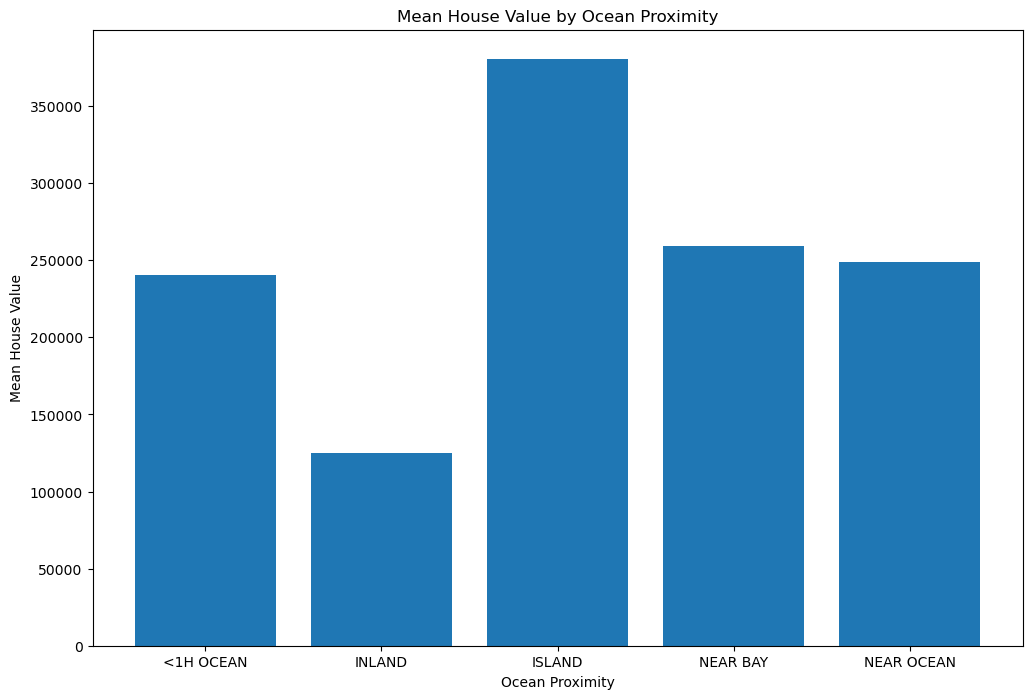

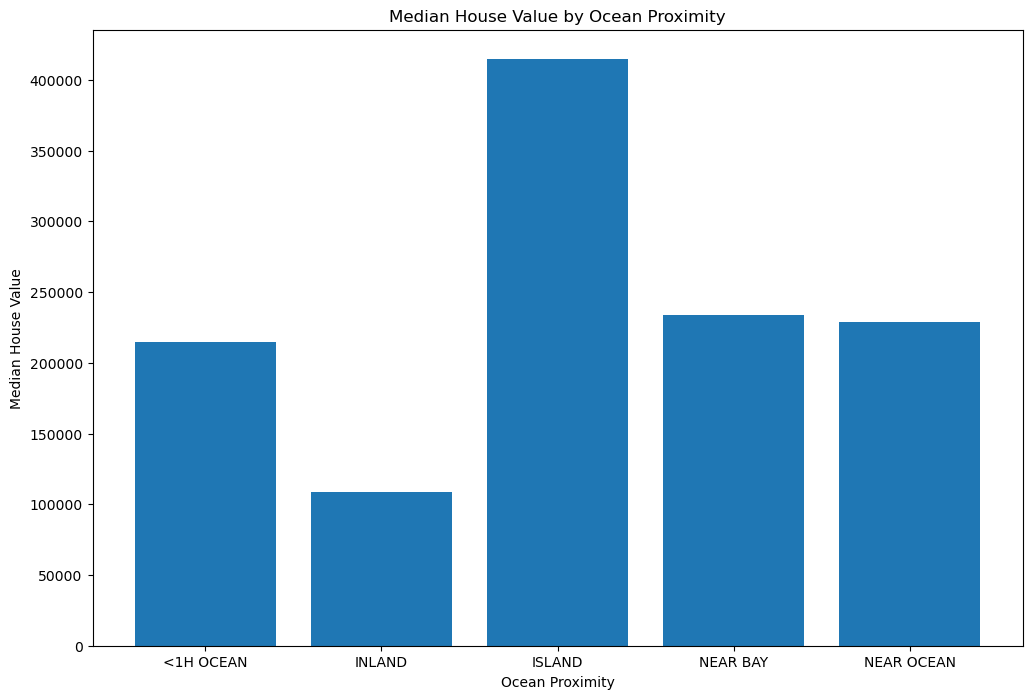

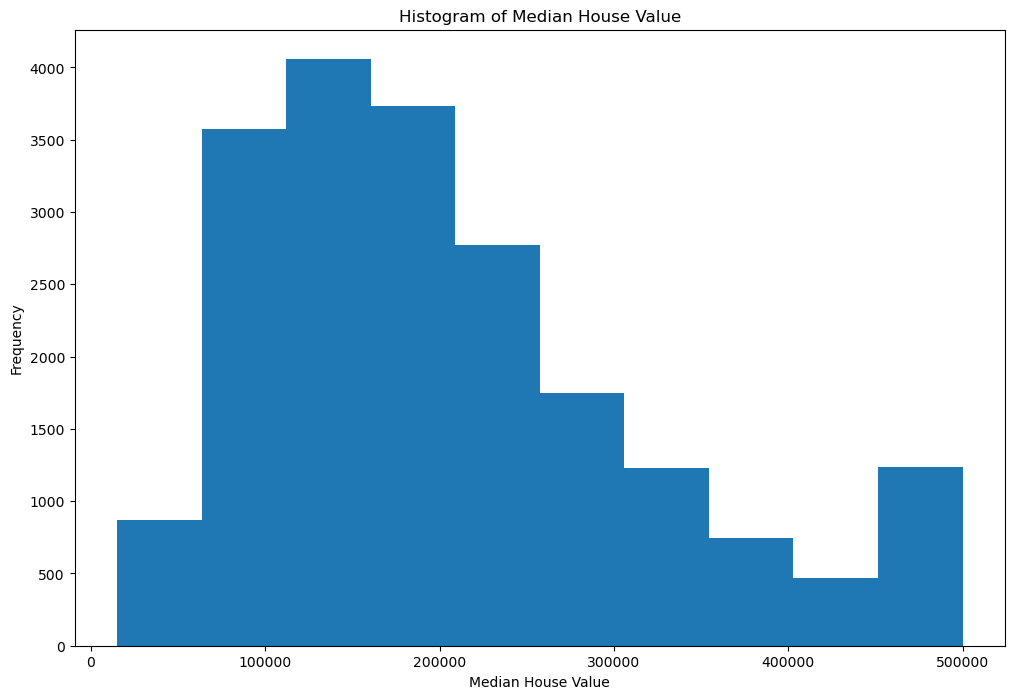

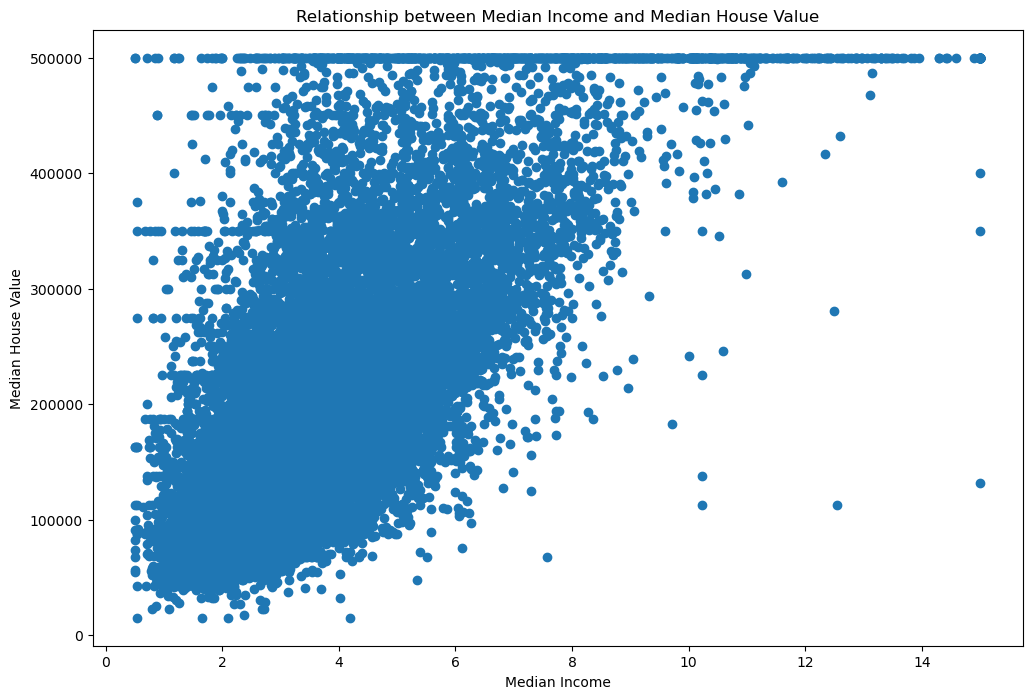

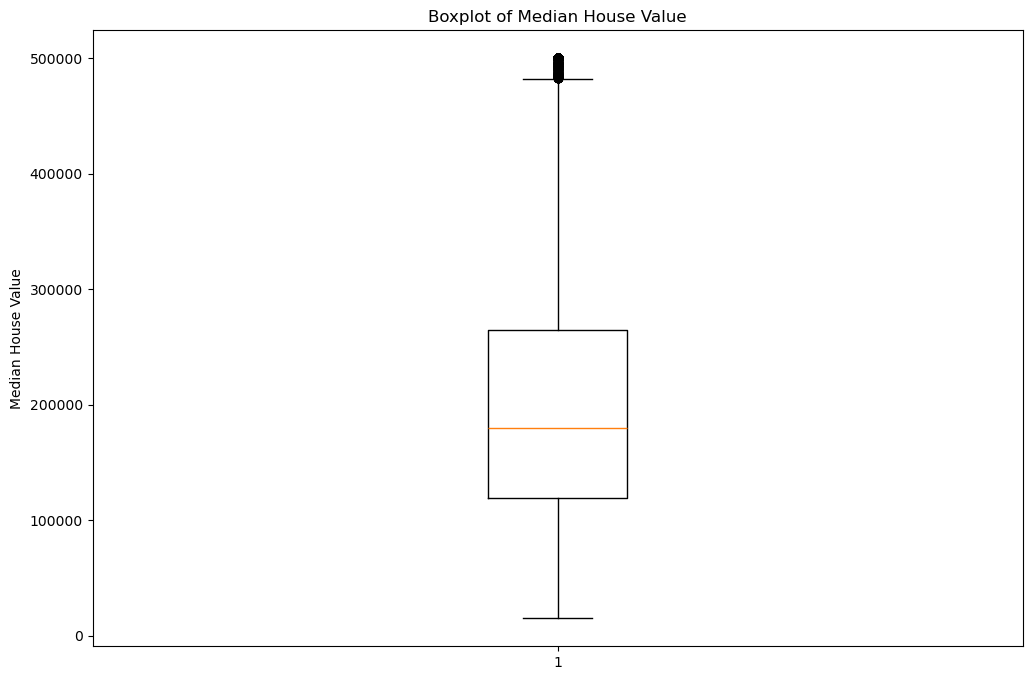

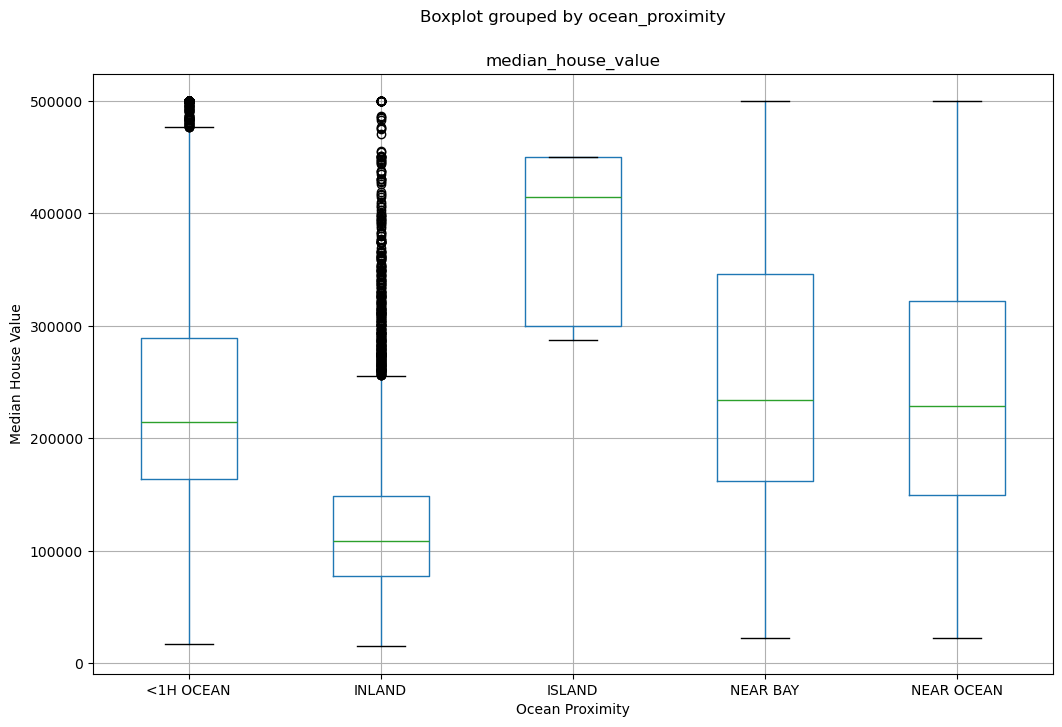

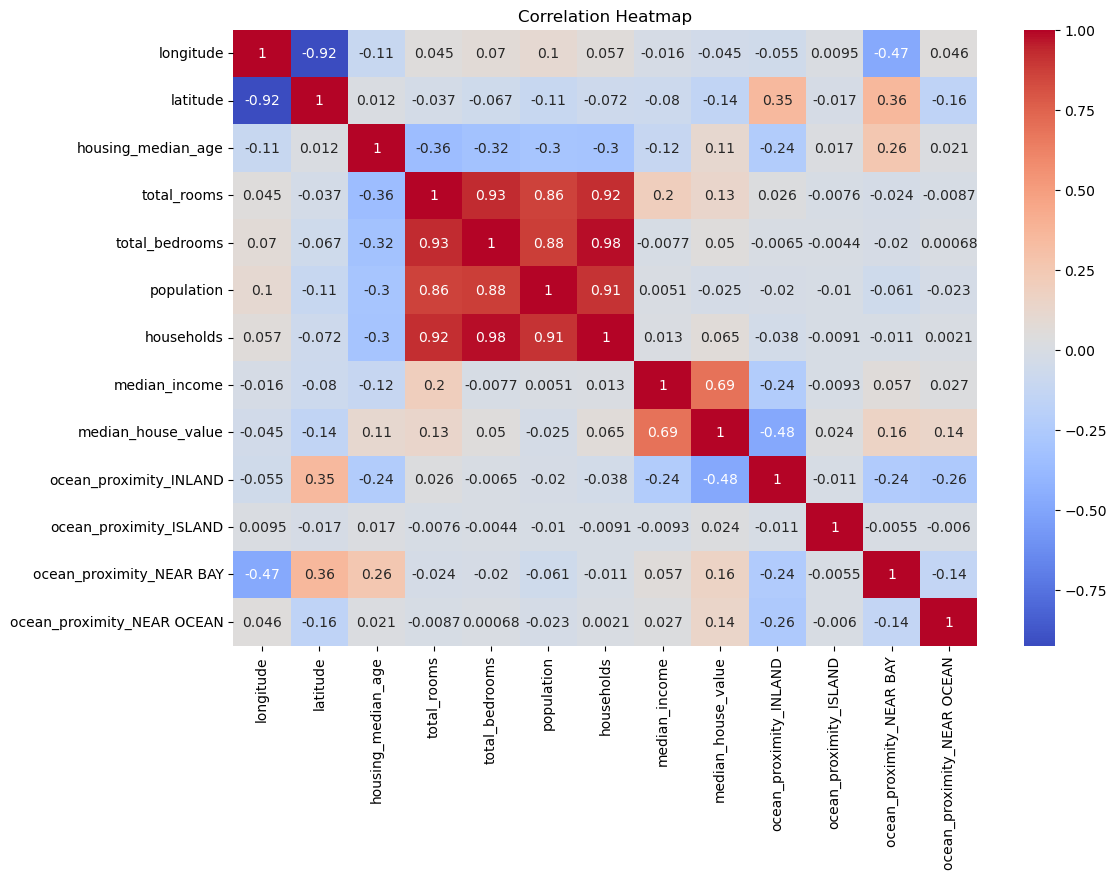

In [505]:
# bar charts to visualize the mean and median house values by ocean proximity
plt.rcParams["figure.figsize"] = (12, 8)

plt.bar(dmean.index, dmean.values)
plt.xlabel("Ocean Proximity")
plt.ylabel("Mean House Value")
plt.title("Mean House Value by Ocean Proximity")
plt.show()

plt.bar(dmedian.index, dmedian.values)
plt.xlabel("Ocean Proximity")
plt.ylabel("Median House Value")
plt.title("Median House Value by Ocean Proximity")
plt.show()

# histogram to visualize the distribution of median house values
plt.hist(data["median_house_value"])
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.title("Histogram of Median House Value")
plt.show()

# scatter plot to visualize the relationship between median income and median house value
plt.scatter(data["median_income"], data["median_house_value"])
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Relationship between Median Income and Median House Value")
plt.show()

# box plot to visualize the distribution of median house values
plt.boxplot(data["median_house_value"])
plt.ylabel("Median House Value")
plt.title("Boxplot of Median House Value")
plt.show()

# box plot to visualize the distribution of median house values by ocean proximity
data.boxplot(column="median_house_value", by="ocean_proximity")
plt.xlabel("Ocean Proximity")
plt.ylabel("Median House Value")
plt.show()

# Correlation between features
new_data = pd.get_dummies(data, columns=["ocean_proximity"], drop_first=True)
correlation = new_data.corr(numeric_only=True)
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [506]:
# Chart to visualize the relationship between median income and median house value 
from scipy import stats



result = stats.linregress(data["median_income"], data["median_house_value"])
print(f"Slope: {result.slope:.2f}")
print(f"Intercept: {result.intercept:.2f}") 
print(f"R-squared: {result.rvalue**2:.2f}")
print(f"P-value: {result.pvalue:.2e}")
print(f"Standard Error: {result.stderr:.2f}")

# We can see that there is a correlation between median income and median house value but its not a strong one

Slope: 41837.07
Intercept: 44906.37
R-squared: 0.47
P-value: 0.00e+00
Standard Error: 308.44


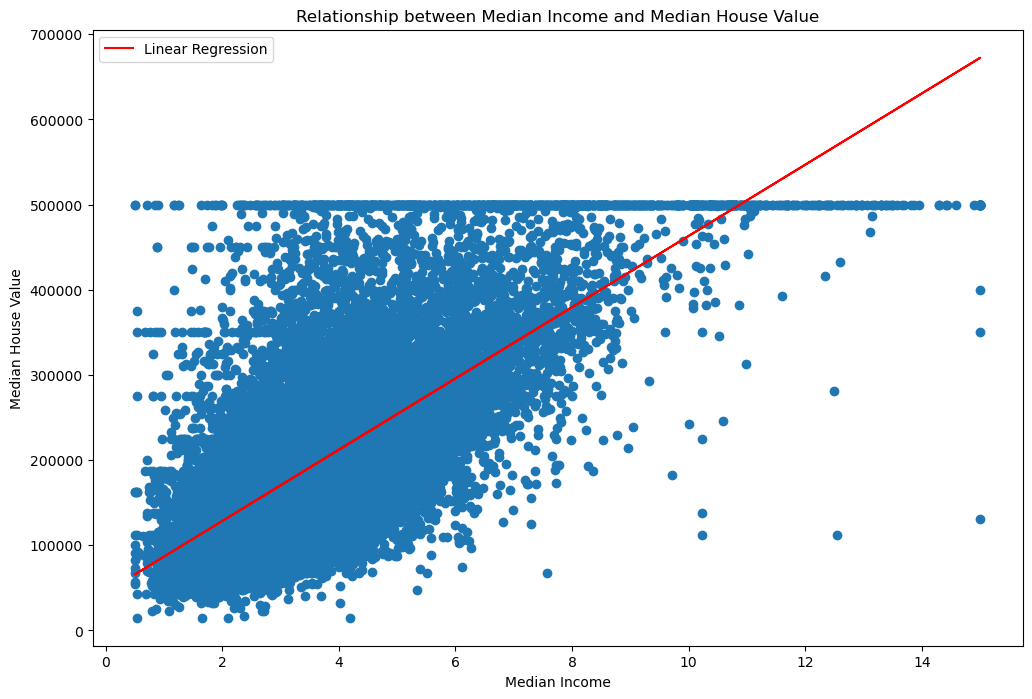

In [507]:
# Chart to visualize the relationship between median income and median house value with the linear regression line

plt.scatter(data["median_income"], data["median_house_value"])
plt.plot(data["median_income"], result.intercept + result.slope * data["median_income"], label = "Linear Regression", color="red")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Relationship between Median Income and Median House Value")
plt.legend()
plt.show()

In [508]:

# Linear regression to predict median house value based on features
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Prepare the data for linear regression
# The model predicts median house value based on other features
X = new_data.drop(columns=["median_house_value"])
y = new_data["median_house_value"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Create a linear regression model and fit it to the training data
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the testing data
y_pred = model.predict(X_test)

# Evaluate the performance of the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}\n")



rmse = np.sqrt(mse)
r_percentage = r2 * 100

# copied the dataset
linear_data = new_data.copy()

#Only makes predictions on the test set which it hasn't seen
linear_data.loc[X_test.index, "predicted_median_house_value"] = y_pred
linear_data["residuals"] = linear_data["median_house_value"] - linear_data["predicted_median_house_value"]

#removes rows with missing values in the predicted_median_house_value and residuals columns
linear_data.dropna(inplace=True)

print(linear_data[["median_house_value", "predicted_median_house_value", "residuals"]].head(10))

print(f"\nThe model's predictions is off by an average of ${rmse:.2f}")
print(f"The model explains {r_percentage:.2f}% of the variance in the median house value")


Mean Squared Error: 4670804827.66
R-squared: 0.65

    median_house_value  predicted_median_house_value      residuals
0             452600.0                 408474.663108   44125.336892
3             341300.0                 320386.642419   20913.357581
6             299200.0                 254260.416453   44939.583547
17            155500.0                 189348.538013  -33848.538013
19            162900.0                 204580.113247  -41680.113247
30            122300.0                 185940.844684  -63640.844684
31            115200.0                 184218.889714  -69018.889714
34            109700.0                 220436.093997 -110736.093997
35             97200.0                 161798.691682  -64598.691682
38            191400.0                 243971.379010  -52571.379010

The model's predictions is off by an average of $68343.29
The model explains 65.48% of the variance in the median house value


In [509]:
# random forest regression to predict median house value based on features
from sklearn.ensemble import RandomForestRegressor

# Prepare the data for random forest regression
X = new_data.drop(columns=["median_house_value"])
y = new_data["median_house_value"]

# Split the data into training and testing sets 
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.25, random_state = 42)

# Create the model and fit it to the training data

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the testing data

y_pred_rf = rf_model.predict(X_test)

# Evaluate the performance of the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Mean Squared Error: {mse_rf:.2f}")
print(f"Random Forest R-squared: {r2_rf:.2f}\n")

rmse_rf = np.sqrt(mse_rf)
r_percentage_rf = r2_rf * 100

# copied the dataset
rf_data = new_data.copy()

# Only makes predictions on the test set which it hasn't seen
rf_data.loc[X_test.index, "predicted_median_house_value"] = y_pred_rf
rf_data["residuals"] = rf_data["median_house_value"] - rf_data["predicted_median_house_value"]

# removes rows with missing values in the predicted_median_house_value and residuals columns
rf_data.dropna(inplace=True)

print(rf_data[["median_house_value", "predicted_median_house_value", "residuals"]].head(10))

print(f"\nThe random forest model's predictions is off by an average of ${rmse_rf:.2f}")
print(f"The random forest model explains {r_percentage_rf:.2f}% of the variance in the median house value")



Random Forest Mean Squared Error: 2365027406.94
Random Forest R-squared: 0.83

    median_house_value  predicted_median_house_value  residuals
0             452600.0                     452521.33      78.67
3             341300.0                     336478.05    4821.95
6             299200.0                     255984.00   43216.00
17            155500.0                     145104.00   10396.00
19            162900.0                     177217.00  -14317.00
30            122300.0                     129853.00   -7553.00
31            115200.0                     129289.00  -14089.00
34            109700.0                     183567.00  -73867.00
35             97200.0                     112846.00  -15646.00
38            191400.0                     221470.00  -30070.00

The random forest model's predictions is off by an average of $48631.55
The random forest model explains 82.52% of the variance in the median house value


In [511]:
# Cat Boost regression to predict median house value based on features 

from catboost import CatBoostRegressor

# Prepare the data

X = data.drop(columns=["median_house_value"])
y = data["median_house_value"]

# Split the data 
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.25, random_state = 42)

# Create the model and fit it to the training data
cb_model = CatBoostRegressor(n_estimators=100, random_state=42)
cb_model.fit(X_train, y_train, cat_features=['ocean_proximity'])

# Make predictions on the testing data
y_pred_cb = cb_model.predict(X_test)

# Evaluate the performance of the model
mse_cb = mean_squared_error(y_test, y_pred_cb)
r2_cb = r2_score(y_test, y_pred_cb)

print(f"Cat Boost Mean Squared Error: {mse_cb:.2f}")
print(f"Cat Boost R-squared: {r2_cb:.2f}\n")

rmse_cb = np.sqrt(mse_cb)
r_percentage_cb = r2_cb * 100

# copied the dataset
cb_data = data.copy()

# Only makes predictions on the test set which it hasn't seen
cb_data.loc[X_test.index, "predicted_median_house_value"] = y_pred_cb
cb_data["residuals"] = cb_data["median_house_value"] - cb_data["predicted_median_house_value"]

# removes rows with missing values in the predicted_median_house_value and residuals columns    
cb_data.dropna(inplace=True)

print(cb_data[["median_house_value", "predicted_median_house_value", "residuals"]].head(10))

print(f"\nThe cat boost model's predictions is off by an average of ${rmse_cb:.2f}")
print(f"The cat boost model explains {r_percentage_cb:.2f}% of the variance in the median house value")

Learning rate set to 0.409702
0:	learn: 93744.4523652	total: 45ms	remaining: 4.46s
1:	learn: 84103.5926740	total: 88.2ms	remaining: 4.32s
2:	learn: 76914.5822259	total: 127ms	remaining: 4.1s
3:	learn: 69886.6645842	total: 177ms	remaining: 4.26s
4:	learn: 66348.5162926	total: 230ms	remaining: 4.37s
5:	learn: 64114.1705447	total: 281ms	remaining: 4.39s
6:	learn: 62376.2586014	total: 329ms	remaining: 4.37s
7:	learn: 61466.5013327	total: 379ms	remaining: 4.36s
8:	learn: 60515.4416406	total: 430ms	remaining: 4.35s
9:	learn: 59675.9350656	total: 480ms	remaining: 4.32s
10:	learn: 58850.9768716	total: 535ms	remaining: 4.33s
11:	learn: 58311.1770408	total: 594ms	remaining: 4.35s
12:	learn: 57619.1764556	total: 647ms	remaining: 4.33s
13:	learn: 57115.4395710	total: 715ms	remaining: 4.39s
14:	learn: 56722.6631984	total: 788ms	remaining: 4.47s
15:	learn: 56321.4459841	total: 845ms	remaining: 4.44s
16:	learn: 55699.4118640	total: 905ms	remaining: 4.42s
17:	learn: 54772.0091072	total: 962ms	remainin